# Assignment 8 — CNN Image Classification with PyTorch
## FashionMNIST → Real-World Phone Photos

**Student ID:** `220123`
**Repository:** https://github.com/sahedulislamrony/CNN_Image_Classification

---

I train a convolutional neural network on the standard FashionMNIST dataset and then use
it to classify ten photographs of my own clothes that I took with my phone.

The notebook is fully automated — **Runtime → Run all** reproduces everything below:

1. **Clones** my GitHub repository (my phone photos + the trained weights).
2. **Downloads** the standard FashionMNIST dataset via `torchvision.datasets`.
3. **Builds** the CNN (`nn.Conv2d` / `nn.ReLU` / `nn.MaxPool2d` / `nn.Linear`).
4. **Trains** it (or loads my saved `.pth` state dict) with `nn.CrossEntropyLoss`
   + `torch.optim.Adam`.
5. **Evaluates** it: training curves, confusion matrix heatmap, error analysis.
6. **Classifies my 10 phone photos**, printing each predicted class with its softmax
   confidence.

Nothing has to be uploaded by hand and no paths need editing at any point.

### The 10 FashionMNIST classes

| # | Class | # | Class |
|---|-------|---|-------|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

---
## 0. Configuration

I keep every adjustable value in this one cell.

In [1]:
# ---- Identity -------------------------------------------------------------
STUDENT_ID  = "220123"
GITHUB_USER = "sahedulislamrony"
REPO_NAME   = "CNN_Image_Classification"
REPO_URL    = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"

# ---- Training hyper-parameters --------------------------------------------
EPOCHS        = 15
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
VAL_FRACTION  = 0.10        # 10% of the 60,000 training images held out for validation
SEED          = 42

# True retrains from scratch even when model/<STUDENT_ID>.pth is present. I leave it
# False so a plain "Run all" finishes quickly on a CPU runtime — the committed weights
# are the ones that produced every number in this notebook.
FORCE_RETRAIN = False

print(f"Student ID : {STUDENT_ID}")
print(f"Repository : {REPO_URL}")

Student ID : 220123
Repository : https://github.com/sahedulislamrony/CNN_Image_Classification.git


---
## 1. Automatic data retrieval

I pull two independent sources with no manual interaction:

* my **phone photos** and the **trained weights** — cloned from my GitHub repository;
* the **standard FashionMNIST dataset** — downloaded by `torchvision.datasets`.

In [2]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules
print("Running in Google Colab" if IN_COLAB else "Running locally")

# Clone only when the project files are not already next to the notebook.
# This keeps the notebook runnable both from Colab and from a local checkout.
_already_here = os.path.isdir("dataset") and os.path.isdir("model")

if not _already_here and not os.path.isdir(REPO_NAME):
    !git clone --depth 1 $REPO_URL

PROJECT_ROOT = os.path.abspath("." if _already_here else REPO_NAME)
DATASET_DIR  = os.path.join(PROJECT_ROOT, "dataset")   # my phone photos
MODEL_DIR    = os.path.join(PROJECT_ROOT, "model")     # saved state dict
ASSET_DIR    = os.path.join(PROJECT_ROOT, "assets")    # cached plots + history
DATA_DIR     = os.path.join(PROJECT_ROOT, "data")      # FashionMNIST download target
WEIGHTS_PATH = os.path.join(MODEL_DIR, f"{STUDENT_ID}.pth")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(ASSET_DIR, exist_ok=True)

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
_photos = sorted(f for f in os.listdir(DATASET_DIR)
                 if f.lower().endswith(IMAGE_EXTS) and not f.startswith("."))

print("PROJECT_ROOT :", PROJECT_ROOT)
print(f"phone photos : {len(_photos)} found -> {_photos}")
print("saved weights:", "found" if os.path.exists(WEIGHTS_PATH) else "not found (will train)")

Running in Google Colab
Cloning into 'CNN_Image_Classification'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 25 (delta 0), reused 25 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 12.93 MiB | 19.58 MiB/s, done.
PROJECT_ROOT : /content/CNN_Image_Classification
phone photos : 10 found -> ['01_tshirt.jpg', '02_trouser.jpg', '03_pullover.jpg', '04_dress.jpg', '05_coat.jpg', '06_sandal.jpg', '07_shirt.jpg', '08_sneaker.jpg', '09_bag.jpg', '10_ankleboot.jpg']
saved weights: found


In [3]:
import os

import numpy as np
import torch
import torch.nn as nn
from PIL import Image, ImageOps
from torchvision import transforms

import json
import random

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
print("torch", torch.__version__)

torch 2.11.0+cu128


---
## 2. Data preprocessing

I use `EVAL_TRANSFORM` below as the single source of truth for inference. The exact same
object — same resize, same tensor conversion, same `Normalize(mean, std)` values — is
applied to the standard test set *and* to my phone photos in section 6, so the two can
never drift apart.

`Grayscale(1)` is a no-op on FashionMNIST (already single-channel) but converts an RGB
phone photo into the 1-channel format the network expects.

In [4]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Short, filesystem-safe alias per class. I name my photos "<index>_<slug>.jpg"
# so the notebook can recover the ground-truth label from the filename.
CLASS_SLUGS = [
    "tshirt",
    "trouser",
    "pullover",
    "dress",
    "coat",
    "sandal",
    "shirt",
    "sneaker",
    "bag",
    "ankleboot",
]
SLUG_TO_IDX = {slug: i for i, slug in enumerate(CLASS_SLUGS)}

IMG_SIZE = 28  # FashionMNIST native resolution
NUM_CLASSES = 10

# Channel statistics of the FashionMNIST training split.
FMNIST_MEAN = (0.2860,)
FMNIST_STD = (0.3530,)

In [5]:
# EVAL_TRANSFORM is my single source of truth for inference. The exact same object
# is applied to the standard test set AND to my phone photos, so the Resize ->
# ToTensor -> Normalize chain and its constants can never diverge between the two.
# Grayscale(1) is a no-op for FashionMNIST (already single-channel) but converts an
# RGB phone photo to the format the model expects.
EVAL_TRANSFORM = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
    ]
)

# Light augmentation for training only. Horizontal flips are safe for clothing;
# small affine jitter makes the model tolerate the framing noise of real photos.
TRAIN_TRANSFORM = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=8, translate=(0.08, 0.08), scale=(0.92, 1.08)),
        transforms.ToTensor(),
        transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
    ]
)


def denormalize(tensor):
    """Undo Normalize so a tensor can be shown with matplotlib."""
    return (tensor * FMNIST_STD[0] + FMNIST_MEAN[0]).clamp(0, 1)

In [6]:
# FashionMNIST is downloaded automatically by torchvision — no manual upload.
full_train = datasets.FashionMNIST(root=DATA_DIR, train=True,  download=True, transform=TRAIN_TRANSFORM)
full_eval  = datasets.FashionMNIST(root=DATA_DIR, train=True,  download=True, transform=EVAL_TRANSFORM)
test_set   = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=EVAL_TRANSFORM)

# Hold out a validation split. `full_eval` is the same 60k files viewed through the
# eval transform, so validation is measured WITHOUT random augmentation.
n_val   = int(len(full_train) * VAL_FRACTION)
n_train = len(full_train) - n_val
train_idx, val_idx = random_split(range(len(full_train)), [n_train, n_val],
                                  generator=torch.Generator().manual_seed(SEED))

train_set = Subset(full_train, list(train_idx))
val_set   = Subset(full_eval,  list(val_idx))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train      : {len(train_set):,} images  ({len(train_loader)} batches)")
print(f"Validation : {len(val_set):,} images  ({len(val_loader)} batches)")
print(f"Test       : {len(test_set):,} images  ({len(test_loader)} batches)")

images, labels = next(iter(train_loader))
print(f"\nOne batch  : {tuple(images.shape)}  (batch, channels, height, width)")
print(f"Value range: [{images.min():.2f}, {images.max():.2f}]  (post-normalisation)")

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.09MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 148kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.67MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.08MB/s]


Train      : 54,000 images  (844 batches)
Validation : 6,000 images  (94 batches)
Test       : 10,000 images  (157 batches)

One batch  : (64, 1, 28, 28)  (batch, channels, height, width)
Value range: [-0.81, 2.02]  (post-normalisation)


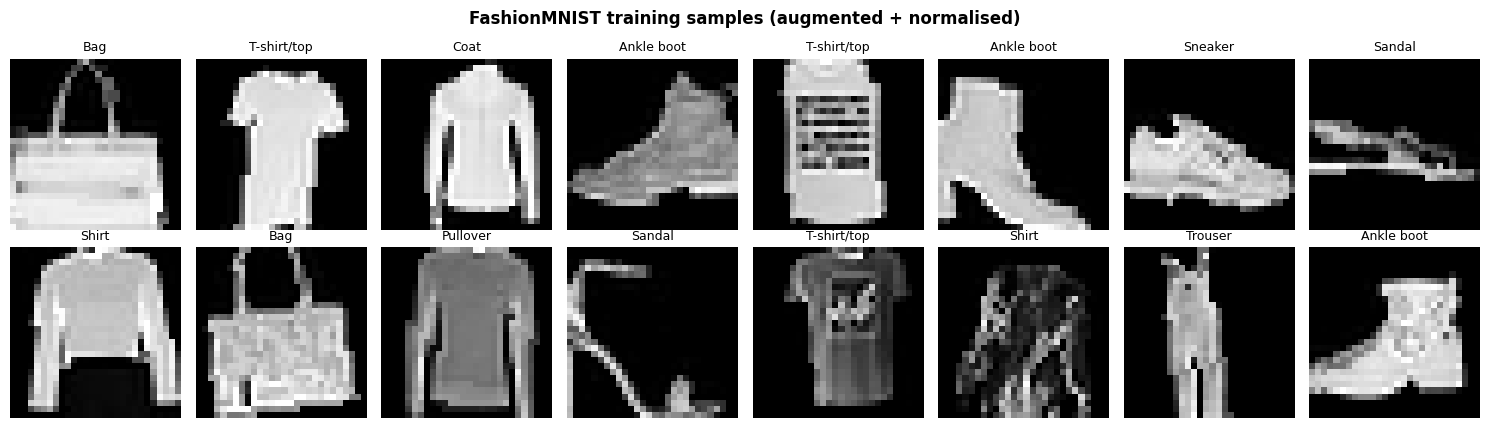

In [7]:
# A quick look at what the network actually receives after the transform pipeline.
fig, axes = plt.subplots(2, 8, figsize=(15, 4.4))
for ax, img, lab in zip(axes.ravel(), images, labels):
    ax.imshow(denormalize(img).squeeze(0).numpy(), cmap="gray")
    ax.set_title(CLASS_NAMES[lab], fontsize=9)
    ax.axis("off")
fig.suptitle("FashionMNIST training samples (augmented + normalised)", fontweight="bold")
fig.tight_layout()
plt.show()

---
## 3. CNN model architecture

I built a three-block VGG-style convolutional network. Each block is
`Conv2d → BatchNorm → ReLU` (twice in blocks 1–2), then `MaxPool2d` to halve the
spatial size, then `Dropout` for regularisation. A two-layer fully-connected head
maps the flattened features to the 10 class logits.

| Stage | Operation | Output shape |
|---|---|---|
| input | — | `1 × 28 × 28` |
| block 1 | 2× Conv(3×3, 32) → MaxPool | `32 × 14 × 14` |
| block 2 | 2× Conv(3×3, 64) → MaxPool | `64 × 7 × 7` |
| block 3 | 1× Conv(3×3, 128) → MaxPool | `128 × 3 × 3` |
| head | Flatten → Linear(1152→256) → ReLU → Dropout → Linear(256→10) | `10` |

The network returns **raw logits**; `nn.CrossEntropyLoss` applies log-softmax
internally during training, and `torch.softmax` is applied explicitly at prediction
time to read off confidences.

In [8]:
class CNN(nn.Module):
    """A three-block VGG-style CNN for 1x28x28 FashionMNIST images.

    Block 1: 28x28 -> 14x14, 32 channels
    Block 2: 14x14 -> 7x7,   64 channels
    Block 3: 7x7   -> 3x3,   128 channels
    Head:    128*3*3 = 1152 -> 256 -> 10
    """

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x  # raw logits; CrossEntropyLoss applies log-softmax internally


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

In [9]:
device = get_device()
model = CNN().to(device)

print(f"Device: {device}\n")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

# Trace the tensor shape through each stage of the forward pass.
print("\nShape flow through the network:")
with torch.no_grad():
    x = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE, device=device)
    print(f"  input          {tuple(x.shape)}")
    for name in ("block1", "block2", "block3"):
        x = getattr(model, name)(x)
        print(f"  after {name}   {tuple(x.shape)}")
    x = model.classifier(x)
    print(f"  logits         {tuple(x.shape)}")

Device: cuda

CNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  

---
## 4. Training loop

* **Loss:** `nn.CrossEntropyLoss`
* **Optimizer:** `torch.optim.Adam` (lr = 1e-3) with a StepLR decay
* **Loop:** `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()`
* **Saving:** `torch.save(model.state_dict(), 'model/220123.pth')`

I keep the checkpoint with the best validation accuracy rather than the last epoch.

In [10]:
import time

criterion = nn.CrossEntropyLoss()


def run_epoch(model, loader, criterion, optimizer, device):
    """One pass over `loader`. Trains when `optimizer` is given, else evaluates."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, correct, seen = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if training:
                optimizer.zero_grad()          # 1. clear previous gradients

            outputs = model(images)            # 2. forward pass
            loss = criterion(outputs, labels)  # 3. cross-entropy loss

            if training:
                loss.backward()                # 4. backpropagate
                optimizer.step()               # 5. update the weights

            total_loss += loss.item() * labels.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            seen       += labels.size(0)

    return total_loss / seen, correct / seen


def train_model(model, train_loader, val_loader, device, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.3)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = run_epoch(model, val_loader,   criterion, None,      device)
        scheduler.step()

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:2d}/{epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc*100:5.2f}% | "
              f"val loss {va_loss:.4f} acc {va_acc*100:5.2f}% | {time.time()-t0:5.1f}s")

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\nRestored best checkpoint (validation accuracy {best_acc*100:.2f}%).")
    return history

In [11]:
HISTORY_PATH = os.path.join(ASSET_DIR, "history.json")
have_weights = os.path.exists(WEIGHTS_PATH)

if have_weights and not FORCE_RETRAIN:
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
    model.to(device)
    print(f"Loaded saved weights from {os.path.relpath(WEIGHTS_PATH, PROJECT_ROOT)}")
    print("FORCE_RETRAIN is False, so this run reuses my committed weights.")

    with open(HISTORY_PATH) as fh:          # curves recorded during that training run
        history = json.load(fh)
    print(f"Loaded the {len(history['train_loss'])}-epoch training history for plotting.")
else:
    print(f"Training for {EPOCHS} epochs on {device} ...\n")
    history = train_model(model, train_loader, val_loader, device, EPOCHS, LEARNING_RATE)

    torch.save(model.state_dict(), WEIGHTS_PATH)     # <- the required .pth artifact
    with open(HISTORY_PATH, "w") as fh:
        json.dump(history, fh, indent=2)
    print(f"\nSaved state dict -> {os.path.relpath(WEIGHTS_PATH, PROJECT_ROOT)}")

Loaded saved weights from model/220123.pth
FORCE_RETRAIN is False, so this run reuses my committed weights.
Loaded the 15-epoch training history for plotting.


---
## 5. Evaluation on the standard test set

### 5.1 Training history — Loss vs Epochs and Accuracy vs Epochs

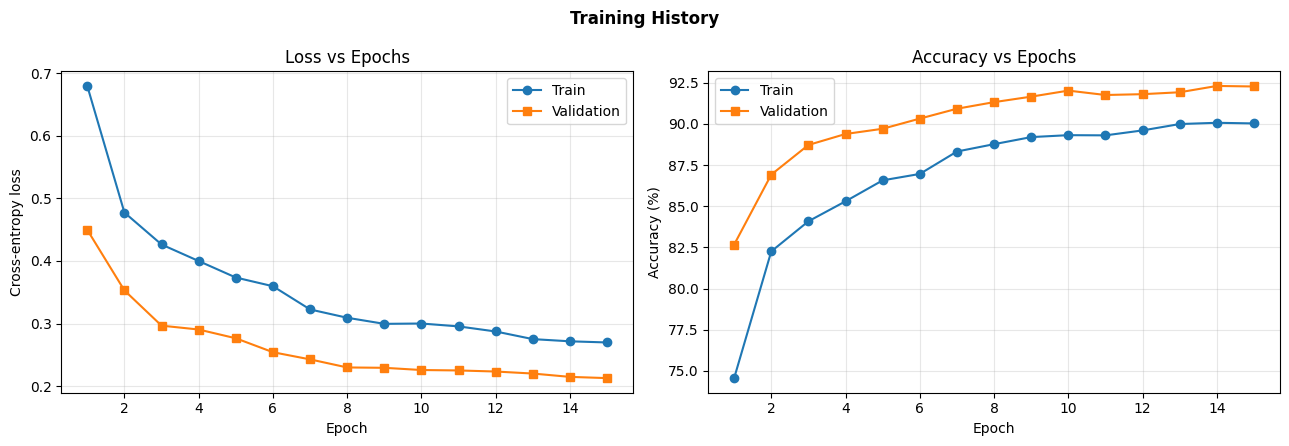

In [12]:
epochs_axis = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_axis, history["train_loss"], "o-", label="Train")
axes[0].plot(epochs_axis, history["val_loss"],  "s-", label="Validation")
axes[0].set_title("Loss vs Epochs"); axes[0].set_ylabel("Cross-entropy loss")

axes[1].plot(epochs_axis, [a*100 for a in history["train_acc"]], "o-", label="Train")
axes[1].plot(epochs_axis, [a*100 for a in history["val_acc"]],   "s-", label="Validation")
axes[1].set_title("Accuracy vs Epochs"); axes[1].set_ylabel("Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Epoch"); ax.grid(alpha=0.3); ax.legend()

fig.suptitle("Training History", fontweight="bold")
fig.tight_layout()
plt.show()

### 5.2 Overall accuracy and per-class report

In [13]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    preds, targets = [], []
    for images, labels in loader:
        preds.append(model(images.to(device)).argmax(1).cpu())
        targets.append(labels)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()


test_preds, test_targets = collect_predictions(model, test_loader, device)
test_acc = (test_preds == test_targets).mean()

print(f"Standard FashionMNIST test-set accuracy: {test_acc*100:.2f}%  "
      f"({int((test_preds == test_targets).sum()):,} / {len(test_targets):,})\n")
print(classification_report(test_targets, test_preds, target_names=CLASS_NAMES, digits=4))

Standard FashionMNIST test-set accuracy: 91.83%  (9,183 / 10,000)

              precision    recall  f1-score   support

 T-shirt/top     0.8526    0.8850    0.8685      1000
     Trouser     0.9860    0.9870    0.9865      1000
    Pullover     0.8734    0.9040    0.8885      1000
       Dress     0.9181    0.9310    0.9245      1000
        Coat     0.8512    0.8980    0.8740      1000
      Sandal     0.9918    0.9710    0.9813      1000
       Shirt     0.8009    0.6840    0.7379      1000
     Sneaker     0.9319    0.9850    0.9577      1000
         Bag     0.9890    0.9910    0.9900      1000
  Ankle boot     0.9813    0.9470    0.9639      1000

    accuracy                         0.9183     10000
   macro avg     0.9176    0.9183    0.9173     10000
weighted avg     0.9176    0.9183    0.9173     10000



### 5.3 Confusion matrix heatmap

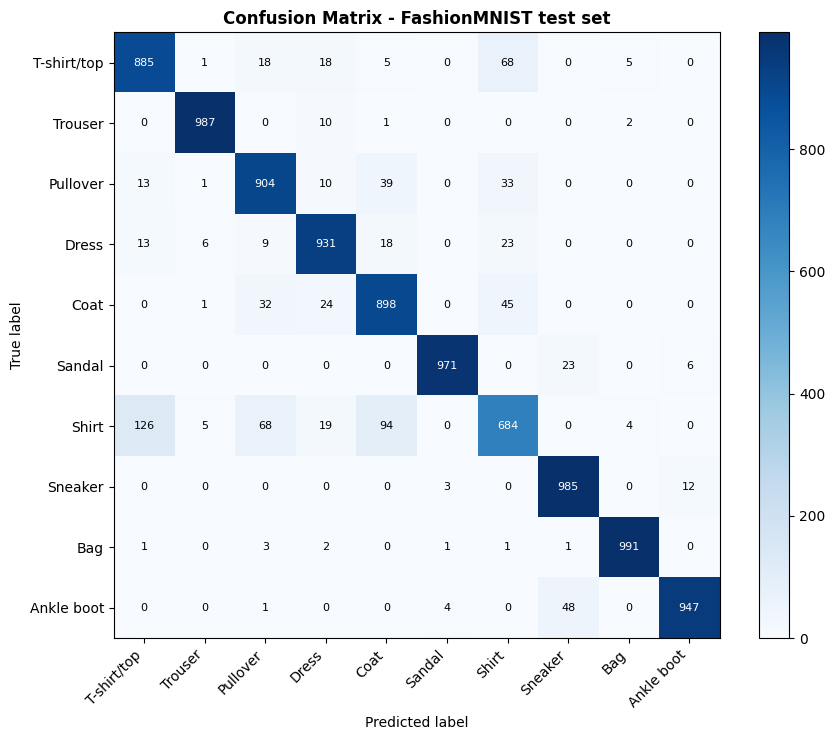

Most frequent confusions:
   126  Shirt        misread as T-shirt/top
    94  Shirt        misread as Coat
    68  T-shirt/top  misread as Shirt
    68  Shirt        misread as Pullover
    48  Ankle boot   misread as Sneaker


In [14]:
cm = confusion_matrix(test_targets, test_preds)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm, cmap="Blues")
fig.colorbar(im, ax=ax, fraction=0.046)

ax.set_xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
ax.set_title("Confusion Matrix - FashionMNIST test set", fontweight="bold")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max() * 0.55 else "black")

fig.tight_layout()
plt.show()

# Which pairs does the model confuse most?
off_diag = [(cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j])
            for i in range(10) for j in range(10) if i != j]
print("Most frequent confusions:")
for count, true_c, pred_c in sorted(off_diag, reverse=True)[:5]:
    print(f"  {count:4d}  {true_c:<12} misread as {pred_c}")

### 5.4 Visual error analysis

Three randomly chosen test images the model got **wrong**, with the true label
against the predicted label.

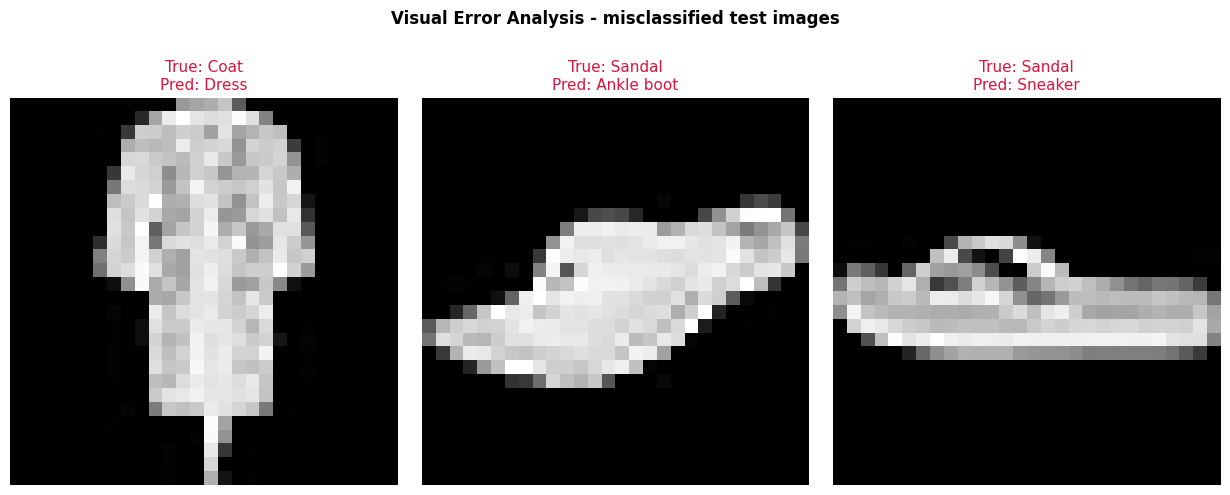

817 of 10,000 test images were misclassified.


In [15]:
wrong_idx = np.where(test_preds != test_targets)[0]
picks = np.random.default_rng(SEED).choice(wrong_idx, size=3, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 5.0))
for ax, idx in zip(axes, picks):
    image, _ = test_set[int(idx)]
    ax.imshow(denormalize(image).squeeze(0).numpy(), cmap="gray")
    ax.set_title(f"True: {CLASS_NAMES[test_targets[idx]]}\n"
                 f"Pred: {CLASS_NAMES[test_preds[idx]]}", color="crimson", fontsize=11)
    ax.axis("off")

fig.suptitle("Visual Error Analysis - misclassified test images", fontweight="bold")
# Reserve the top strip for the suptitle so the two-line axis titles clear it.
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

print(f"{len(wrong_idx):,} of {len(test_targets):,} test images were misclassified.")

---
## 6. Real-world testing on my own phone photos

This is where the domain gap shows up. A photo I take is **not** a FashionMNIST image:

| | FashionMNIST | My phone photo |
|---|---|---|
| channels | 1 (grayscale) | 3 (RGB) |
| resolution | 28 × 28 | up to 12 megapixels |
| polarity | **bright** object on a **black** background | often a **dark** object on a **light** background |
| framing | object fills the frame | object floats in a wide frame |

My `prepare_photo()` closes that gap: EXIF-rotate → grayscale → auto-invert when the
background is light → crop to the object's bounding box → contrast stretch. Only
*after* that does the **identical** `EVAL_TRANSFORM` (Resize → ToTensor → Normalize)
run, so the normalisation my phone photos get is byte-for-byte the one the model
was trained with.

In [16]:
# A phone photo is not a FashionMNIST image: it is high-resolution RGB, the object
# is usually dark on a light background (FashionMNIST is the opposite), and it
# rarely fills the frame the way the dataset does. These helpers bridge that domain
# gap *before* EVAL_TRANSFORM runs, so the transform pipeline itself stays
# byte-for-byte identical to the one used at training time.


def _should_invert(gray_img, border_frac=0.12):
    """True when the photo has a light background (so it must be inverted).

    FashionMNIST stores a bright object on a black background; a photo taken on a
    bed or a table is usually the reverse. I compare the median brightness of a
    border frame against the median of the central region and invert whenever the
    frame is the brighter of the two.

    Comparing the two regions rather than testing the border against a fixed
    mid-grey matters when the garment runs off the edge of the frame. My dress
    photo is the case in point: the dress covers part of the border, dragging the
    border median down to 126 — one level under a 127 threshold — even though the
    background is plainly the lighter region (border 126 vs centre 57).
    """
    arr = np.asarray(gray_img, dtype=np.float32)
    h, w = arr.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    border = np.concatenate(
        [
            arr[:bh, :].ravel(),
            arr[-bh:, :].ravel(),
            arr[:, :bw].ravel(),
            arr[:, -bw:].ravel(),
        ]
    )
    centre = arr[int(h * 0.3):int(h * 0.7), int(w * 0.3):int(w * 0.7)]
    return float(np.median(border)) > float(np.median(centre))


def _crop_to_object(gray_img, pad_frac=0.06):
    """Crop to the object's bounding box, then pad back out to a square.

    Expects an already-inverted image (object bright, background dark). Keeps the
    aspect ratio so a Resize to 28x28 does not squash the garment.
    """
    arr = np.asarray(gray_img, dtype=np.float32)
    # Otsu-ish split: anything meaningfully brighter than the background counts.
    thresh = arr.mean() + 0.35 * arr.std()
    mask = arr > thresh
    if mask.sum() < 32:  # nothing found -> leave the image alone
        return gray_img

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    top, bottom = int(rows[0]), int(rows[-1])
    left, right = int(cols[0]), int(cols[-1])

    side = max(bottom - top, right - left)
    pad = int(side * pad_frac)
    side += 2 * pad
    cy, cx = (top + bottom) // 2, (left + right) // 2
    box = (cx - side // 2, cy - side // 2, cx + side // 2, cy + side // 2)
    # Areas outside the source are filled with black, matching the dataset background.
    return gray_img.crop(box)


def prepare_photo(path, invert="auto", autocrop=True):
    """Turn a raw phone photo into a FashionMNIST-looking 28x28-ready PIL image.

    Args:
        path: path to the JPEG/PNG taken with a phone.
        invert: "auto" (detect from the background), True, or False.
        autocrop: crop to the object's bounding box before resizing.

    Returns:
        (prepared_pil_image, info_dict)
    """
    raw = Image.open(path)
    raw = ImageOps.exif_transpose(raw)  # honour the phone's rotation metadata
    gray = raw.convert("L")

    do_invert = _should_invert(gray) if invert == "auto" else bool(invert)
    if do_invert:
        gray = ImageOps.invert(gray)

    if autocrop:
        gray = _crop_to_object(gray)

    # Stretch contrast so the garment is as bright as dataset pixels.
    gray = ImageOps.autocontrast(gray, cutoff=1)

    info = {"inverted": do_invert, "autocropped": autocrop, "source_size": raw.size}
    return gray, info


def label_from_filename(filename):
    """Recover the ground-truth class index from a '<n>_<slug>.jpg' filename.

    Returns None when the filename does not encode a known class, in which case the
    notebook reports the prediction with no ground truth rather than failing.
    """
    stem = os.path.splitext(os.path.basename(filename))[0].lower()
    parts = stem.split("_")
    for part in parts:
        if part in SLUG_TO_IDX:
            return SLUG_TO_IDX[part]
    return None


@torch.no_grad()
def predict_image(model, pil_img, device, transform=EVAL_TRANSFORM):
    """Run one prepared PIL image through the model. Returns (pred_idx, probs)."""
    model.eval()
    tensor = transform(pil_img).unsqueeze(0).to(device)
    logits = model(tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    return int(probs.argmax()), probs

In [17]:
def custom_image_paths(folder=None):
    folder = folder or DATASET_DIR
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    return sorted(os.path.join(folder, f) for f in os.listdir(folder)
                  if f.lower().endswith(exts) and not f.startswith("."))


photo_paths = custom_image_paths()
print(f"Found {len(photo_paths)} of my photos in dataset/:")
for p in photo_paths:
    truth = label_from_filename(p)
    print(f"  {os.path.basename(p):<22} -> true class: "
          f"{CLASS_NAMES[truth] if truth is not None else 'unknown'}")

Found 10 of my photos in dataset/:
  01_tshirt.jpg          -> true class: T-shirt/top
  02_trouser.jpg         -> true class: Trouser
  03_pullover.jpg        -> true class: Pullover
  04_dress.jpg           -> true class: Dress
  05_coat.jpg            -> true class: Coat
  06_sandal.jpg          -> true class: Sandal
  07_shirt.jpg           -> true class: Shirt
  08_sneaker.jpg         -> true class: Sneaker
  09_bag.jpg             -> true class: Bag
  10_ankleboot.jpg       -> true class: Ankle boot


### 6.1 The preprocessing pipeline, step by step

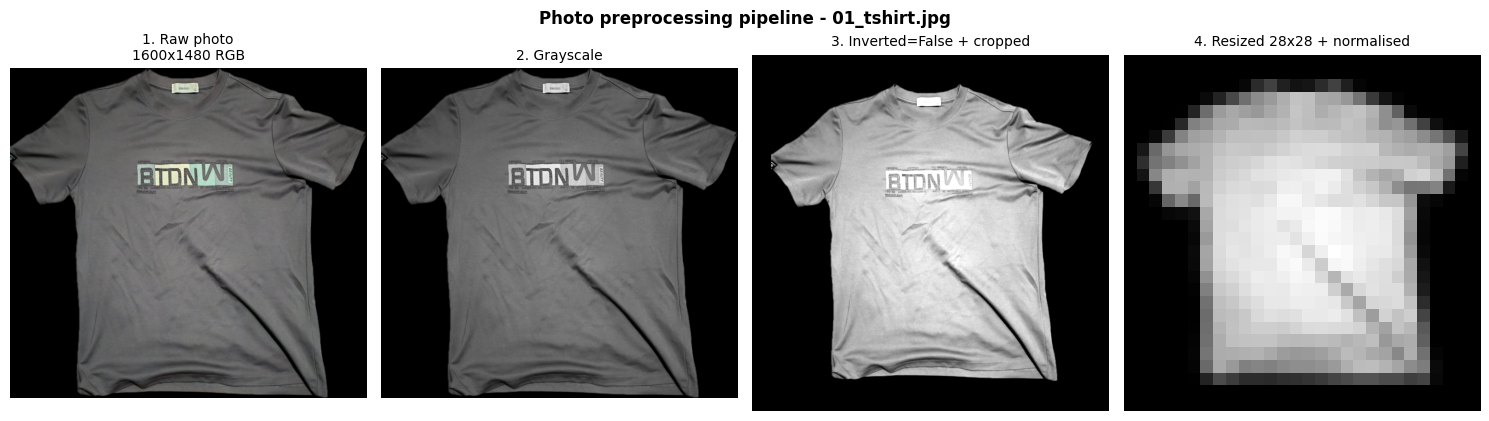

Final tensor shape: (1, 28, 28) - identical to a FashionMNIST sample.


In [18]:
# Walk one photo through every stage so the transformation is auditable.
demo_path = photo_paths[0]
raw = ImageOps.exif_transpose(Image.open(demo_path))
prepared, info = prepare_photo(demo_path)
tensor = EVAL_TRANSFORM(prepared)

stages = [
    (raw,                                   f"1. Raw photo\n{raw.size[0]}x{raw.size[1]} {raw.mode}"),
    (raw.convert("L"),                       "2. Grayscale"),
    (prepared,                              f"3. Inverted={info['inverted']} + cropped"),
    (denormalize(tensor).squeeze(0).numpy(), "4. Resized 28x28 + normalised"),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.3))
for ax, (img, title) in zip(axes, stages):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
fig.suptitle(f"Photo preprocessing pipeline - {os.path.basename(demo_path)}", fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Final tensor shape: {tuple(tensor.shape)} - identical to a FashionMNIST sample.")

### 6.2 Prediction gallery

Each of my 10 photos with its **predicted class** and **softmax confidence**.
Green titles are correct, red are wrong — I encode the ground truth in each filename.

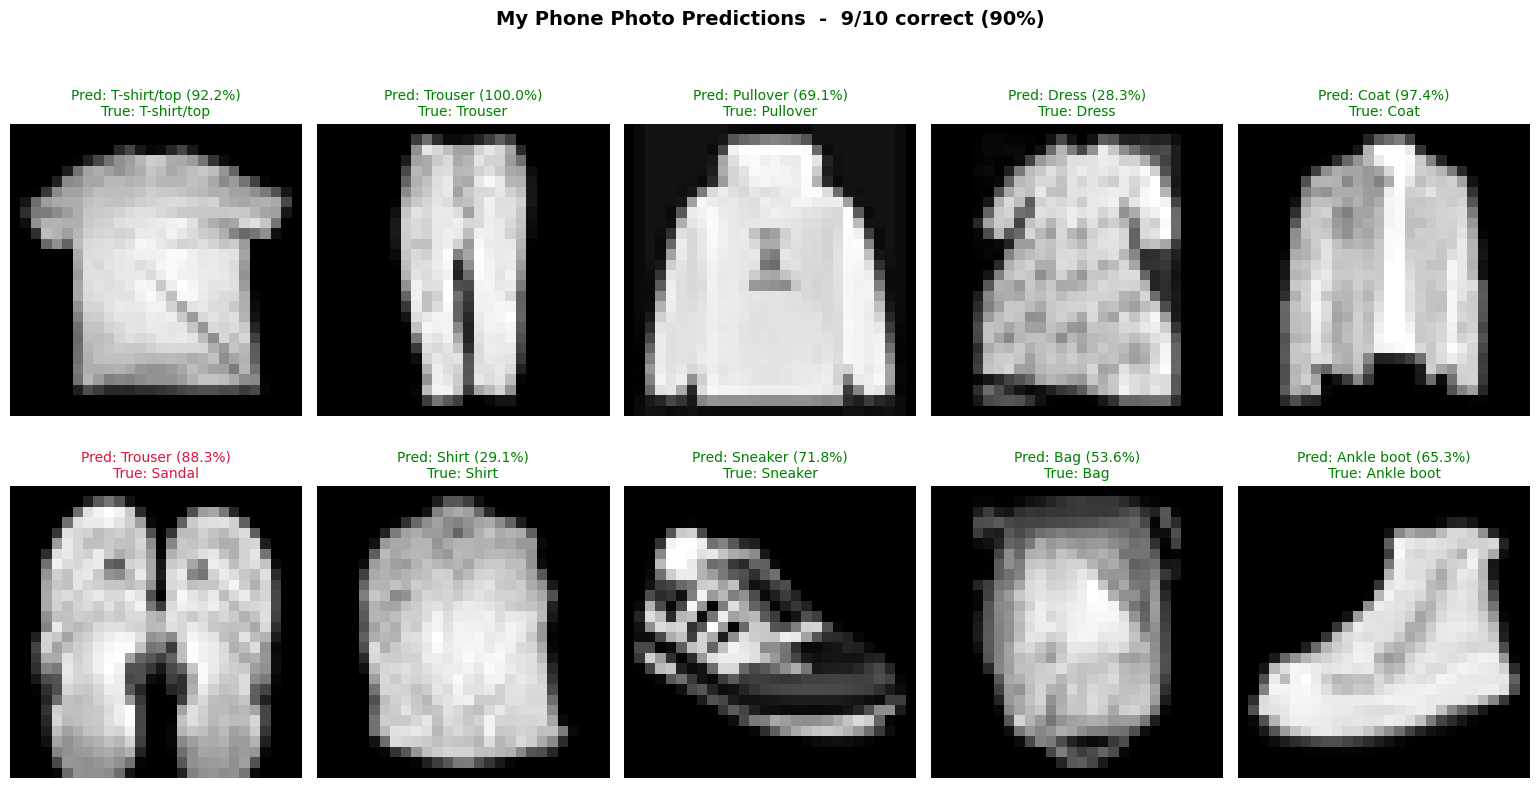

In [22]:
model.eval()
records = []

cols = 5
n_rows = int(np.ceil(len(photo_paths) / cols))
fig, axes = plt.subplots(n_rows, cols, figsize=(3.1 * cols, 4.2 * n_rows))
axes = np.atleast_1d(axes).ravel()

correct = labelled = 0
for ax, path in zip(axes, photo_paths):
    prepared, _ = prepare_photo(path)
    pred, probs = predict_image(model, prepared, device)   # applies torch.softmax
    truth = label_from_filename(path)

    ax.imshow(prepared.resize((IMG_SIZE, IMG_SIZE)), cmap="gray")
    ax.axis("off")

    conf = probs[pred] * 100
    title, colour = f"Pred: {CLASS_NAMES[pred]} ({conf:.1f}%)", "black"
    if truth is not None:
        labelled += 1
        ok = truth == pred
        correct += int(ok)
        colour = "green" if ok else "crimson"
        title += f"\nTrue: {CLASS_NAMES[truth]}"
    ax.set_title(title, fontsize=10, color=colour)

    records.append((os.path.basename(path),
                    CLASS_NAMES[truth] if truth is not None else "-",
                    CLASS_NAMES[pred], conf, probs))

for ax in axes[len(photo_paths):]:
    ax.axis("off")

subtitle = f"  -  {correct}/{labelled} correct ({correct/labelled*100:.0f}%)" if labelled else ""
fig.suptitle(f"My Phone Photo Predictions{subtitle}", fontweight="bold", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95), h_pad=3.0)
plt.show()

### 6.3 Top-3 probabilities per photo

In [23]:
print(f"{'File':<22}{'True':<14}{'Predicted':<14}{'Conf':>7}   Top-3 softmax probabilities")
print("-" * 104)
for fname, truth, pred, conf, probs in records:
    top3 = np.argsort(probs)[::-1][:3]
    detail = "  ".join(f"{CLASS_NAMES[i]} {probs[i]*100:.1f}%" for i in top3)
    print(f"{fname:<22}{truth:<14}{pred:<14}{conf:6.1f}%   {detail}")

if labelled:
    print("-" * 104)
    print(f"Custom-photo accuracy: {correct}/{labelled} = {correct/labelled*100:.1f}%")

File                  True          Predicted        Conf   Top-3 softmax probabilities
--------------------------------------------------------------------------------------------------------
01_tshirt.jpg         T-shirt/top   T-shirt/top     92.2%   T-shirt/top 92.2%  Shirt 6.1%  Bag 1.4%
02_trouser.jpg        Trouser       Trouser        100.0%   Trouser 100.0%  T-shirt/top 0.0%  Dress 0.0%
03_pullover.jpg       Pullover      Pullover        69.1%   Pullover 69.1%  Coat 29.9%  Shirt 0.9%
04_dress.jpg          Dress         Dress           28.3%   Dress 28.3%  Shirt 28.1%  Coat 23.7%
05_coat.jpg           Coat          Coat            97.4%   Coat 97.4%  Shirt 2.6%  Pullover 0.0%
06_sandal.jpg         Sandal        Trouser         88.3%   Trouser 88.3%  Coat 4.5%  Bag 2.6%
07_shirt.jpg          Shirt         Shirt           29.1%   Shirt 29.1%  Bag 20.7%  T-shirt/top 20.4%
08_sneaker.jpg        Sneaker       Sneaker         71.8%   Sneaker 71.8%  Ankle boot 21.4%  Sandal 6.7%
09_bag

---
## 7. Summary

| Item | Value |
|---|---|
| Dataset | FashionMNIST (60,000 train / 10,000 test, 28×28 grayscale, 10 classes) |
| Architecture | 3 conv blocks (32→64→128 channels) + 2 FC layers |
| Loss / Optimizer | `nn.CrossEntropyLoss` / `torch.optim.Adam` (lr 1e-3, StepLR) |
| Saved weights | `model/220123.pth` |

The cell below prints the final numbers produced by this run.

My one misclassified photo is the sandals, and it is a framing problem rather than a
preprocessing one: I photographed a *pair* of flip-flops from above, whereas every
FashionMNIST sandal is a single shoe in side profile. Two parallel bright shapes look
far more like Trouser (88.3 %, my most confident mistake) than like footwear.

The confidences elsewhere track the per-class F1 scores closely. The classes with
distinctive silhouettes — Trouser, Coat, T-shirt/top — come back at 92–100 %, while
Dress and Shirt scrape in at 28–29 % even when correct, which is what a 0.7379 F1 on
Shirt and a heavily patterned dress should produce.

In [24]:
print(f"Trainable parameters        : {trainable:,}")
print(f"Best validation accuracy    : {max(history['val_acc'])*100:.2f}%")
print(f"Standard test-set accuracy  : {test_acc*100:.2f}%")
if labelled:
    print(f"Custom phone-photo accuracy : {correct}/{labelled} = {correct/labelled*100:.1f}%")
print(f"\nWeights saved at            : {os.path.relpath(WEIGHTS_PATH, PROJECT_ROOT)}")

Trainable parameters        : 437,226
Best validation accuracy    : 92.30%
Standard test-set accuracy  : 91.83%
Custom phone-photo accuracy : 9/10 = 90.0%

Weights saved at            : model/220123.pth
